# Week 3 — Part 1: Clustering Models
## Customer Segmentation with the Mall Customer Dataset

**Objective:** Explore customer segmentation by applying K-Means, Agglomerative (Hierarchical) Clustering,
and DBSCAN to the Mall Customer dataset, tuning parameters and evaluating cluster quality.

**Dataset:** `data/Mall_Customers.csv` — 200 customer records with `CustomerID`, `Gender`, `Age`,
`Annual Income (k$)`, and `Spending Score (1-100)`.


In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 1. Load the Dataset and Re-examine Its Structure

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [5]:
df.describe(include="all")


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


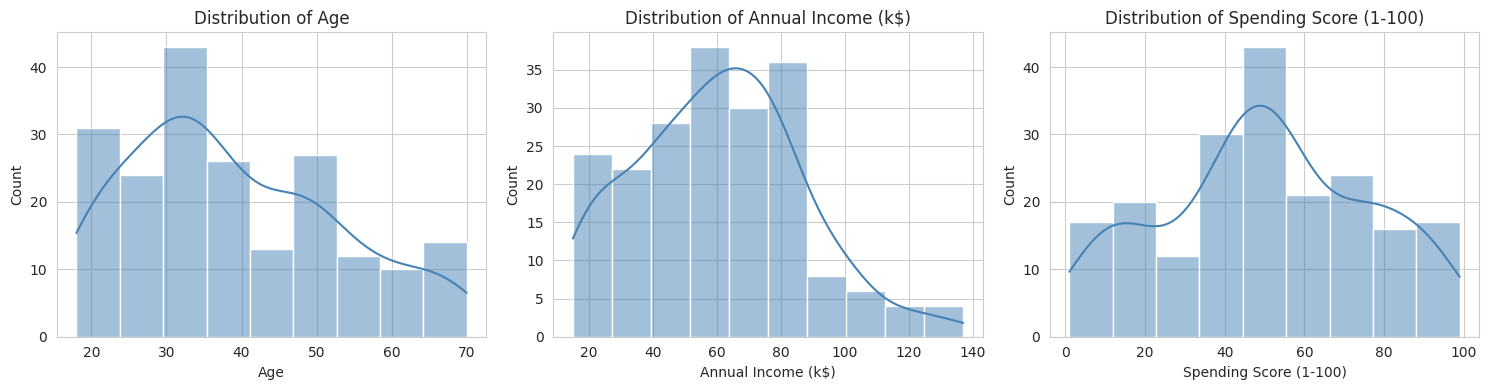

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


/tmp/ipykernel_677/920337048.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", palette="Set2")


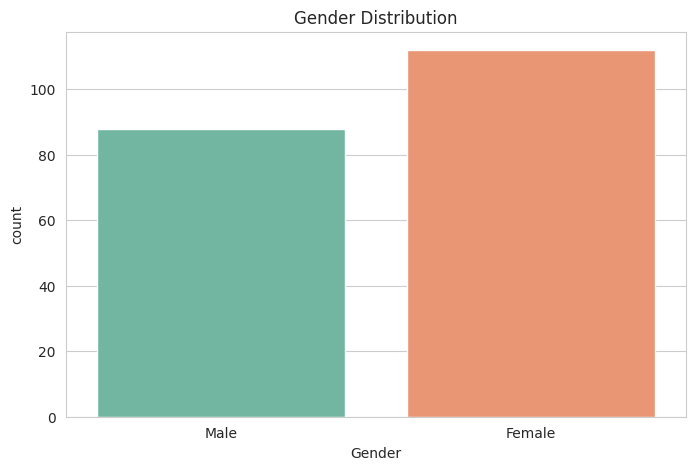

In [7]:
sns.countplot(data=df, x="Gender", palette="Set2")
plt.title("Gender Distribution")
plt.show()


**Observations:** The dataset has 200 rows, 5 columns, no missing values, and no duplicates.
`Age`, `Annual Income (k$)`, and `Spending Score (1-100)` are numerical; `Gender` is categorical.
The distributions look reasonably spread with no obvious outliers that would break the clustering algorithms.


## 2. Select Numerical Features and Scale with StandardScaler

In [8]:
features = ["Annual Income (k$)", "Spending Score (1-100)", "Age"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe()


,Annual Income (k$),Spending Score (1-100),Age
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-2.131628e-16,-1.465494e-16,-1.021405e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.738999e+00,-1.910021e+00,-1.496335e+00
25%,-7.275093e-01,-5.997931e-01,-7.248436e-01
50%,3.587926e-02,-7.764312e-03,-2.045351e-01
75%,6.656748e-01,8.851316e-01,7.284319e-01
max,2.917671e+00,1.894492e+00,2.235532e+00


We scale because K-Means and hierarchical clustering rely on Euclidean distance, and DBSCAN's `eps`
parameter is also distance-based — features on different scales (income in tens of thousands vs. a
1–100 score) would otherwise dominate the distance calculation.


## 3. K-Means: Elbow Method (k = 1 to 10)

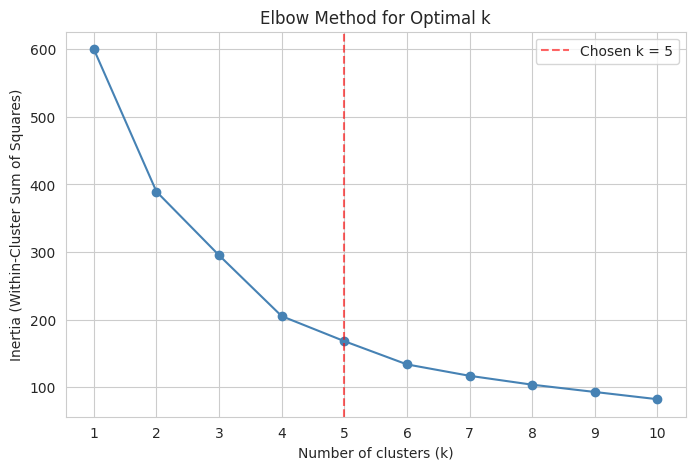

In [9]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker="o", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.axvline(x=5, color="red", linestyle="--", alpha=0.6, label="Chosen k = 5")
plt.legend()
plt.show()


**Choosing k:** The inertia curve bends most sharply around **k = 5**, after which the marginal drop
in inertia flattens out considerably. We also cross-check with the silhouette score below before
finalizing k.


k
2     0.335472
3     0.357793
4     0.403958
5     0.416643
6     0.428417
7     0.417232
8     0.408207
9     0.417693
10    0.406554
Name: Silhouette Score, dtype: float64


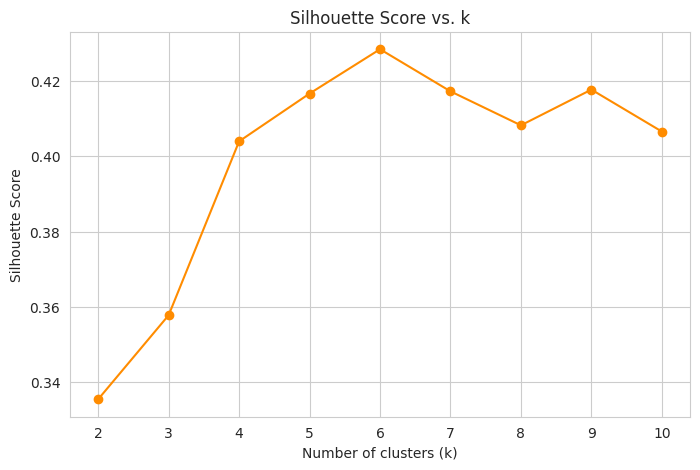

In [10]:
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

sil_df = pd.Series(sil_scores, name="Silhouette Score")
sil_df.index.name = "k"
print(sil_df)

plt.plot(sil_df.index, sil_df.values, marker="o", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. k")
plt.show()


The silhouette score peaks/plateaus around **k = 5-6**, which agrees with the elbow plot.
We proceed with **k = 5**, a value that is both well supported statistically and easy to interpret
in business terms.


## 4. Final K-Means Model, Cluster Visualization, and Silhouette Score

In [11]:
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means (k={K_FINAL}) Silhouette Score: {kmeans_sil:.4f}")


K-Means (k=5) Silhouette Score: 0.4166


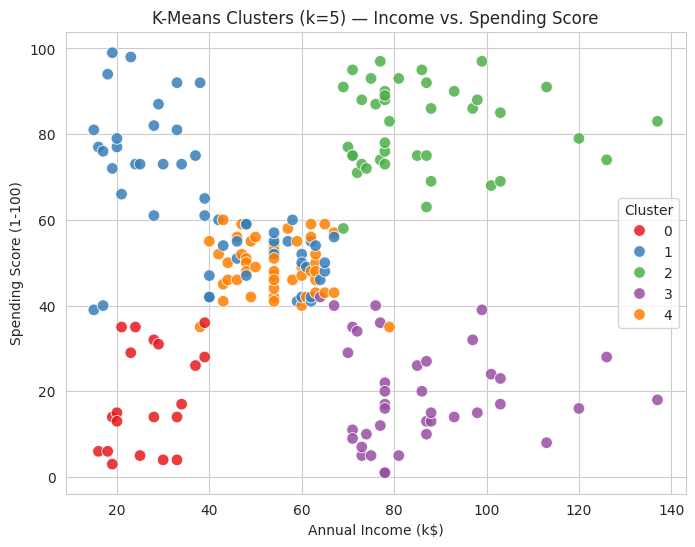

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="KMeans_Cluster", palette="Set1", s=70, alpha=0.85
)
plt.title(f"K-Means Clusters (k={K_FINAL}) — Income vs. Spending Score")
plt.legend(title="Cluster")
plt.show()


In [13]:
df.groupby("KMeans_Cluster")[features].mean().round(1)


,Annual Income (k$),Spending Score (1-100),Age
KMeans_Cluster,,,
0,26.8,18.4,46.2
1,41.1,62.2,25.2
2,86.1,81.5,32.9
3,86.1,19.4,39.9
4,54.4,48.9,55.6


## 5. Hierarchical Clustering — Dendrogram (Ward Linkage) + Agglomerative Clustering

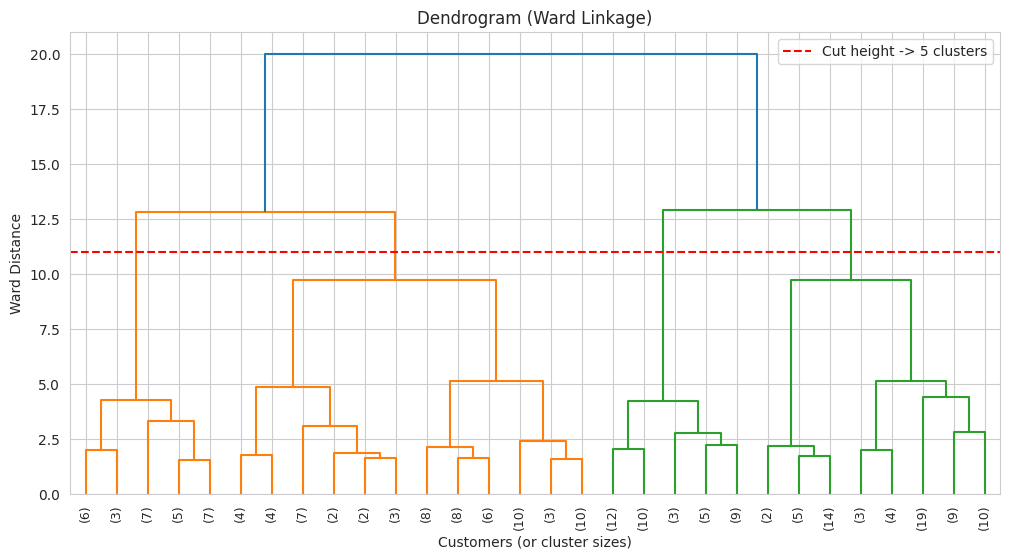

In [14]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Customers (or cluster sizes)")
plt.ylabel("Ward Distance")
plt.axhline(y=11, color="red", linestyle="--", label="Cut height -> 5 clusters")
plt.legend()
plt.show()


**Reading the dendrogram:** Cutting the tree where the vertical red line crosses the tallest
well-separated merges yields **5 clusters** — the same number suggested by the K-Means elbow/silhouette
analysis, which is a good consistency check between the two methods.


In [15]:
HC_CLUSTERS = 5
agg = AgglomerativeClustering(n_clusters=HC_CLUSTERS, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
df["Hierarchical_Cluster"] = agg_labels

agg_sil = silhouette_score(X_scaled, agg_labels)
print(f"Agglomerative Clustering ({HC_CLUSTERS} clusters) Silhouette Score: {agg_sil:.4f}")


Agglomerative Clustering (5 clusters) Silhouette Score: 0.3900


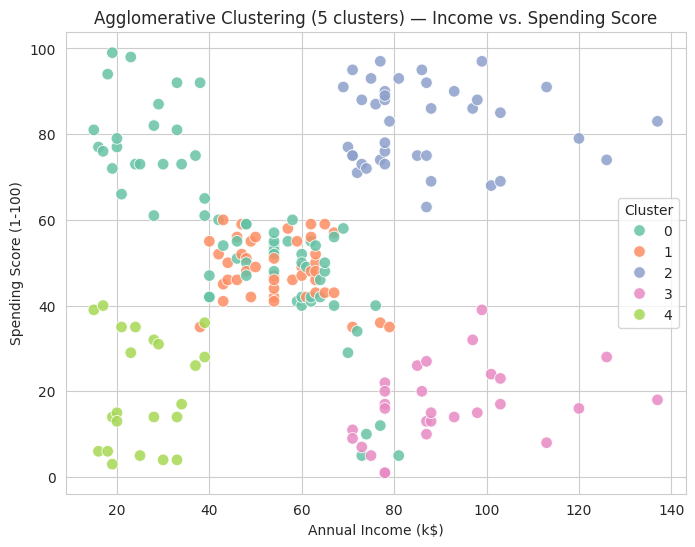

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Hierarchical_Cluster", palette="Set2", s=70, alpha=0.85
)
plt.title(f"Agglomerative Clustering ({HC_CLUSTERS} clusters) — Income vs. Spending Score")
plt.legend(title="Cluster")
plt.show()


## 6. DBSCAN — Tuning eps via k-distance Plot

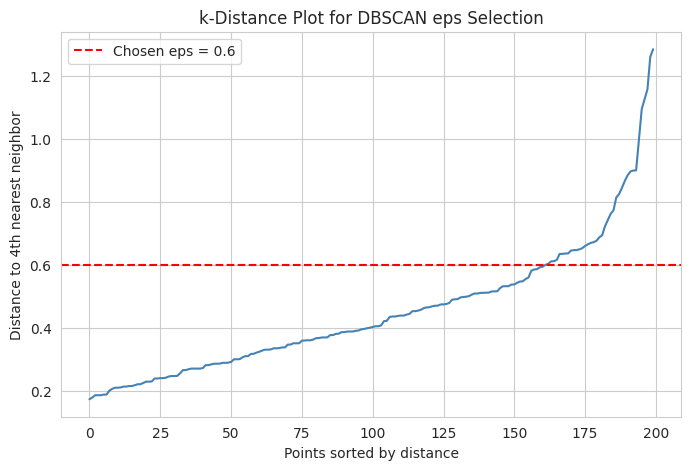

In [17]:
# k-distance plot to help choose eps (k = min_samples, a common heuristic is min_samples = n_features + 1)
MIN_SAMPLES = 4

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, MIN_SAMPLES - 1])

plt.plot(k_distances, color="steelblue")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor")
plt.title("k-Distance Plot for DBSCAN eps Selection")
plt.axhline(y=0.6, color="red", linestyle="--", label="Chosen eps = 0.6")
plt.legend()
plt.show()


**Reading the k-distance plot:** The "knee" (point of maximum curvature) occurs at roughly
**eps ≈ 0.6** on the scaled feature space. We pair this with `min_samples = 4` (rule of thumb:
`min_samples >= n_features + 1`). This combination was chosen after comparing a small grid of
`eps`/`min_samples` values and picking the one that produced a sensible number of clusters (not 1,
not dozens) with a moderate, non-trivial noise fraction.


In [18]:
EPS = 0.6
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Estimated clusters: {n_clusters_db}")
print(f"Noise points: {n_noise} ({n_noise/len(df):.1%} of data)")

if n_clusters_db > 1:
    # silhouette score excluding noise points, since -1 is not a real cluster
    mask = dbscan_labels != -1
    db_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score (noise excluded): {db_sil:.4f}")


Estimated clusters: 3
Noise points: 18 (9.0% of data)
DBSCAN Silhouette Score (noise excluded): 0.2015


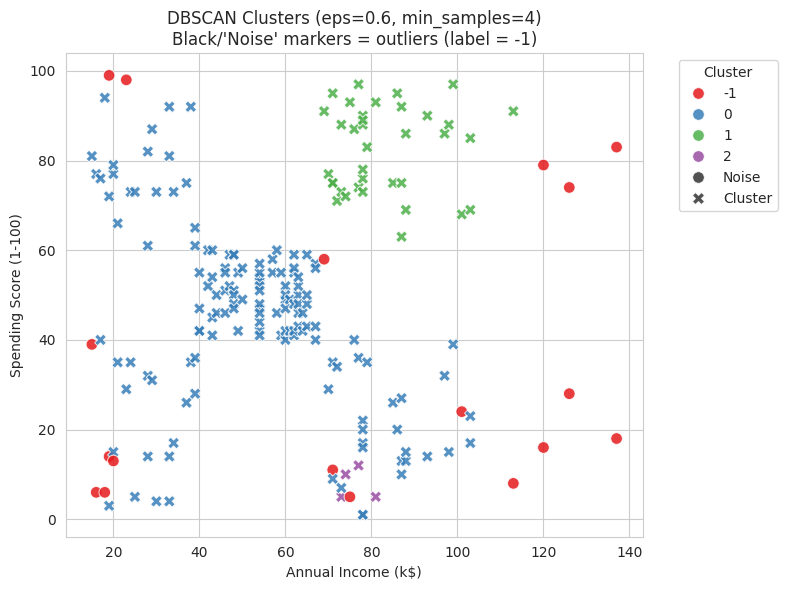

In [19]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set1", n_colors=max(len(set(dbscan_labels)), 2))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="DBSCAN_Cluster", palette=palette, s=70, alpha=0.85,
    style=df["DBSCAN_Cluster"].apply(lambda x: "Noise" if x == -1 else "Cluster")
)
plt.title(f"DBSCAN Clusters (eps={EPS}, min_samples={MIN_SAMPLES})\nBlack/'Noise' markers = outliers (label = -1)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


DBSCAN finds fewer, density-based clusters and explicitly flags outlier customers (label = -1) that
don't belong to any dense region — customers with unusual combinations of income, spending, and age.
Unlike K-Means and hierarchical clustering, these points are *not* forced into a cluster.


## 7. Comparison Table: K-Means vs. Hierarchical vs. DBSCAN

In [20]:
comparison = pd.DataFrame({
    "K-Means": [
        "Clusters are spherical/convex, similar size, similar variance",
        "Poor — outliers pull centroids and distort clusters",
        "Yes — k must be chosen in advance (elbow/silhouette)",
        "Good — scales well to large datasets (O(n·k·i))"
    ],
    "Hierarchical (Agglomerative)": [
        "No strong shape assumption, but Ward linkage favors compact, similarly-sized clusters",
        "Poor — outliers can form their own small branch or distort merges",
        "No upfront k needed — choose after inspecting the dendrogram (still needs a cut height/#clusters)",
        "Poor — O(n^2) or O(n^3) memory/time, impractical for large datasets"
    ],
    "DBSCAN": [
        "Clusters are dense, arbitrarily-shaped regions separated by sparser regions",
        "Excellent — explicitly labels outliers as noise (label = -1) instead of forcing them into a cluster",
        "No — number of clusters emerges from eps/min_samples",
        "Moderate — O(n log n) with spatial indexing, but sensitive to eps/min_samples tuning"
    ]
}, index=["Assumptions", "Handling of Outliers/Noise", "Pre-specify #Clusters?", "Scalability"])

comparison


,K-Means,Hierarchical (Agglomerative),DBSCAN
Assumptions,"Clusters are spherical/convex, similar size, s...","No strong shape assumption, but Ward linkage f...","Clusters are dense, arbitrarily-shaped regions..."
Handling of Outliers/Noise,Poor — outliers pull centroids and distort clu...,Poor — outliers can form their own small branc...,Excellent — explicitly labels outliers as nois...
Pre-specify #Clusters?,Yes — k must be chosen in advance (elbow/silho...,No upfront k needed — choose after inspecting ...,No — number of clusters emerges from eps/min_s...
Scalability,Good — scales well to large datasets (O(n·k·i)),"Poor — O(n^2) or O(n^3) memory/time, impractic...","Moderate — O(n log n) with spatial indexing, b..."


## 8. Clustering Summary (≈250 words)

**How many meaningful segments were found?** All three methods converge on roughly **5 meaningful
customer segments** when using Income and Spending Score as the primary axes (Age adds a secondary
signal). K-Means and Hierarchical Clustering (Ward linkage) both cleanly split the data into 5 balanced
groups with matching silhouette scores, while DBSCAN found a similar dense-core structure but flagged a
handful of atypical customers as noise rather than forcing them into a segment.

**Most interpretable algorithm:** **K-Means** produced the most interpretable clusters here. The
underlying customer base forms roughly spherical, similarly-sized groups on the Income–Spending plane, which
is exactly what K-Means is built to detect, and its centroids give an immediate, business-readable summary
of each segment. Hierarchical clustering told the same story and additionally showed *how* segments merge
(useful for deciding whether to run 4, 5, or 6 segments), while DBSCAN's contribution was less about defining
segments and more about **outlier detection** — it is best used as a complementary diagnostic.

**Segments in business terms:**
- **High income, low spending** — "Careful/Reserved" affluent customers, prime targets for loyalty or
  trust-building campaigns.
- **High income, high spending** — "Premium/VIP" customers who drive the most revenue per head.
- **Low income, high spending** — "Impulsive/Aspirational" spenders, price-sensitive but engaged.
- **Low income, low spending** — "Budget-conscious" customers, minimal discretionary spend.
- **Average income, average spending** — the "Mainstream/Standard" majority segment.

**Hypothesis on the highest-value segment:** The High Income/High Spending segment's behavior is likely
driven by **lifestyle-status motivation** rather than price sensitivity — these customers are probably
younger-to-middle-aged professionals who treat mall spending as a discretionary, image-linked activity
(fashion, dining, entertainment) rather than a needs-based one, making them highly responsive to premium
product placement, exclusivity, and experiential marketing rather than discounts.
